In [ ]:
#SPSS 파일을 읽는 라이브라리
%pip install pyreadstat

In [ ]:
import pandas as pd #데이터 프레임용
import numpy as np #수학연산용

import matplotlib.pyplot as plt #그래프용
import seaborn as sns  #그래프 더 이쁘게

#시각화 스타일 설정 : 배경 흰색, 파스텔 톤
sns.set_style('white')
sns.set_palette('pastel')

#한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

#마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


In [ ]:
df = pd.read_spss('data/Koweps_hpwc20_2025_beta1.sav') 

df.head() # 데이터 상위 5개 확인, head(n): n개 확인

In [ ]:
df.tail() # 데이터 하위 5개 확인, tail(n) : n개 확인

In [ ]:
# 원본 데이터 보존용 백업
raw_data = df.copy()

In [ ]:
df.info() # 데이터 전체 구조 파악

In [ ]:
df.columns # 데이터프레임 모든 변수명 출력

In [ ]:
df.describe() # 수치형 변수(숫자형 변수)의 통계 요약

h20_g3 성별
h20_g4 출생연도
h20_eco9 직종
p2002_8aq1 월평균 임금

In [ ]:
df[['h20_g3', 'h20_g4','h20_eco9', 'p2002_8aq1']]

In [ ]:
data = df.rename(columns ={
    'h20_g3' : 'sex',
    'h20_g4' : 'birth',
    'h20_eco9' : 'job_code',
    'p2002_8aq1' : 'income'
} )


data

In [ ]:
data = data[['sex','birth','job_code','income']]

data

In [ ]:
data.describe()

In [ ]:
data['sex'].unique() #고유값(카테고리)이 있는지 확인, 1 = 남성, 2 = 여성

In [ ]:
# 결측치 개수 확인 (=isna.sum)
data['sex'].isnull().sum() 

In [ ]:
# 값별 빈도수 확인
data['sex'].value_counts()

np.where(조건, 참일때 값, 거짓일 때 값): 조건에 따라 선택적으로 변환하는 함수

In [ ]:
# 성별 컬럼이 1.0이면 'M', 그렇지 않으면 'F'
data['sex'] = np.where(data['sex'] == 1.0, 'M', 'F')

In [ ]:
# 성별 데이터 빈도수 막대그래프
sns.countplot(x = 'sex', data = data)

In [ ]:
data

In [ ]:
data['income'].describe()

In [ ]:
sns.histplot(x = 'income', data = data)

In [ ]:
data['income'].isna().sum()

In [ ]:
na_rate = data.isnull().mean().sort_values(ascending = False)

In [ ]:
plt.figure(figsize=(6,3))
na_rate.plot(kind="bar")
plt.title('결측치 비율')
plt.ylabel('결측비율')

plt.show()

In [ ]:

tmp = data.assign(income_missing = data['income'].isna())
tmp

In [ ]:
# 성별별 임금 결측치 수 확인

sns.barplot(x = 'sex' , y ='income_missing' ,data =tmp )
plt.title('성별별 임금 결측치 수')
plt.show()

In [ ]:
# 소득에 결측치가 있는 행 제거
sex_income = data.dropna(subset = ['income'])
sex_income.isnull().sum()

In [ ]:
#성별로 그룹화시키고 평균 소득 계산

sex_income.groupby('sex')['income'].mean()
sex_income

In [ ]:
#plot.bar():
sex_income.plot.bar()

In [ ]:
tmp = data.dropna(subset = ['income'])

plt.figure(figsize = (6, 4))
sns.boxplot(x = 'sex', y = 'income', data = tmp)
plt.title("성별별 수입 박스플롯")
plt.yscale('log')  #y값에 로그 스케일 적용(이상치 완화)
plt.show()

In [ ]:
#남성 소득이 여성 소득에 비해 몇 배 높은지 확인
sex_income['M']/ sex_income['F']

In [ ]:
#t-test를 통해 성별 소득 차이의 통계적 유의성 검정
import scipy.stats as stats

sex_m = data[data['sex'] == 'M'].dropna()
sex_f = data[data['sex'] == 'F'].dropna()

stats.ttest_ind(sex_m['income'], sex_f['income'], equal_var = True)

t - test 결과 해석
statistic(t-값) : 값이 크면 두 집단의 평균 차이가 크다.

p_value : 0에 거의 근접 -> p_value 기준인 0.05보다 작다 -> 귀무가설 기각
남성과 여성의 평균 소득에는 유의미한 차이가 있다.

ttest_ind() : 통계적 유의성 검정
equal_var = True : 두 집단이 등분산을 가정

In [ ]:
data['birth'].describe()

In [ ]:
sns.histplot(x = 'birth', data =data)

In [ ]:
# age 컬럼 = 2026 - 출생연도

data['age'] = 2026 - data['birth']
data

In [ ]:
# 나이 컬럼을 정수형으로 변환
data['age'] = data['age'].astype(int)
data

In [ ]:
# 소득 결측치 제거
data_income = data.dropna(subset = ['income'])
data_income.isnull().sum()


#나이별 평균 소득 계산
data_income = data_income.groupby('age')['income'].mean()
data_income


#선 그래프 시각화
data_income.plot()

In [ ]:
data_income.max()           #나이대별 가장 높은 소득
print(data_income.idxmax()) #가장 소득이 높은 나이

In [ ]:
# 나이별 평균 소득을 내림차순 정렬
data_income

In [ ]:
data_income.sort_values(ascending = False)

In [ ]:
data = data.assign(
    agetype = np.where(
        data['age'] < 30, 'youth',
        np.where(
            data['age'] < 60, 'middle age', 'senior')
        )
    )


data

assign(): 기존 데이터프레임에 새로운 파생 변수 추가
np.where(조건, 참일때 값, 거짓일 때 값) : 조건에 따라 선택적으로 변환하는 함수

In [ ]:
#연령대별 응답자 수 막대그래프
sns.countplot(x = 'agetype', data = data)

In [ ]:
# 연령대별 평균 소득 계산
data.groupby('agetype')['income'].mean()

In [ ]:
# (연령대, 성별) 조합으로 그룹화하고 평균 소득 계산
data.groupby(['agetype','sex'])['income'].mean()

In [ ]:
#소득 결측치 제거 후, (성별x나이)로 그룹화하여 평균 소득 계산
# as_index = False : 그룹화한 컬럼을 인덱스로 쓰지않음
data.dropna(subset = ['income']).groupby(
    ['sex','age'], as_index = False 
)['income'].mean()

In [ ]:
sns.lineplot(x ='age' , y = 'income', data=age_sex_income, hue = 'sex')

In [ ]:
#남성/여성 소득 비율 그래프
#unstack() : 인덱스에 있던 값을 컬럼으로 펼쳐준다.
age_mean = data.dropna(subset = ['income']).groupby(['age','sex'])['income'].mean().unstack()

age_mean['ratio_M_over_F'] = age_mean['M'] / age_mean['F']
age_mean

In [ ]:
age_mean['ratio_M_over_F'].plot(figsize = (8,3))
plt.axhline(1,linestyle =  '--')
plt.title('연령대별 남여 소득비율')
plt.ylabel('M/F')
plt.show()

In [ ]:
data

In [ ]:
len(data['job_code'].unique()) #직종코드 고유값 수

In [ ]:
sheet_name = '직종코드(2019 7차 신분류)'

job_name = pd.read_excel('data/(2025년 20차 한국복지패널조사) 조사설계서-가구용(beta1).xlsx',
sheet_name = '직종코드(2019 7차 신분류)'
)

job_name

In [ ]:
#소분류 -> job_code, Unnamed: 3 -> job, inplace = True

#job_name 데이터프레임에 job_code, job만 남기기

In [ ]:
job_name.rename(
    columns ={'소분류' : 'job_code','Unnamed: 3' : 'job'},
    inplace = True 
)

job_name = job_name[['job_code','job']]

job_name

In [ ]:
#data(분석 데이터)와 job_name(직업별 매핑표)을 job_code 기준으로 매핑하여 결합
job_df = data.merge(job_name, how='left', on = 'job_code')

job_df

In [ ]:
#직업명과 소득이 모두 존재하는(결측치가 없는) 행만 필터링
job_income_mean = job_df.dropna(subset =['job','income'])


#작업명을 기준으로 그룹화하여 평균 소득 계산
job_income_mean = job_income_mean.groupby('job')['income'].mean()

job_income_mean

In [ ]:
#직업별 평균 소득을 내림차순으로 정렬하고 상위 10개만 출력
job_income_mean.sort_values(ascending = False).head(10)


In [ ]:
top10 = job_income_mean.sort_values(ascending = False).head(10).sort_values()
plt.figure(figsize = (8,5))
top10.plot(kind = "barh")
plt.title('상위 10개 직업 평균 소득 랭킹')
plt.xlabel('평균 소득')
plt.show()

In [ ]:
# 평균 소득 하위 10개 직업만 조회
job_income_mean.sort_values(ascending = False).tail(10)

In [ ]:
# 평균 소득 하위 10개 직업 시각화

top10 = job_income_mean.sort_values(ascending = False).tail(10).sort_values()
plt.figure(figsize = (8,5))
top10.plot(kind = "barh")
plt.title('하위 10개 직업 평균 소득 랭킹')
plt.xlabel('평균 소득')
plt.show()

In [ ]:
#월평균임금 p2002_8aq1
# 정치성향 wc20_5aq6


In [336]:
data = df.rename(columns ={
    'wc20_5aq6' : 'politic',
    'p2002_8aq1' : 'income',
    'h20_g4' : 'birth',
} )

In [337]:
data = data[['politic','income','birth']]

data

,politic,income,birth
3,3,235.000000,1962.0
4,4,190.000000,1963.0
12,4,304.979532,1962.0
13,3,300.000000,1978.0
15,3,304.979532,2004.0
...,...,...,...
14543,2,304.979532,2004.0
14645,3,304.979532,2004.0
14778,3,304.979532,2002.0
14810,6,304.979532,2004.0


In [338]:
# income의 평균을 구해서 빈 곳에 채워 넣기
data['income'] = data['income'].dropna()
data

,politic,income,birth
3,3,235.000000,1962.0
4,4,190.000000,1963.0
12,4,304.979532,1962.0
13,3,300.000000,1978.0
15,3,304.979532,2004.0
...,...,...,...
14543,2,304.979532,2004.0
14645,3,304.979532,2004.0
14778,3,304.979532,2002.0
14810,6,304.979532,2004.0


In [339]:
# age 컬럼 = 2026 - 출생연도

data['age'] = 2026 - data['birth']
data

,politic,income,birth,age
3,3,235.000000,1962.0,64.0
4,4,190.000000,1963.0,63.0
12,4,304.979532,1962.0,64.0
13,3,300.000000,1978.0,48.0
15,3,304.979532,2004.0,22.0
...,...,...,...,...
14543,2,304.979532,2004.0,22.0
14645,3,304.979532,2004.0,22.0
14778,3,304.979532,2002.0,24.0
14810,6,304.979532,2004.0,22.0


In [340]:
#정치로 그룹화시키고 평균 소득 계산
data = data.dropna(subset=['politic'])
data.groupby('politic')['income'].mean()
data

,politic,income,birth,age
3,3,235.000000,1962.0,64.0
4,4,190.000000,1963.0,63.0
12,4,304.979532,1962.0,64.0
13,3,300.000000,1978.0,48.0
15,3,304.979532,2004.0,22.0
...,...,...,...,...
14543,2,304.979532,2004.0,22.0
14645,3,304.979532,2004.0,22.0
14778,3,304.979532,2002.0,24.0
14810,6,304.979532,2004.0,22.0


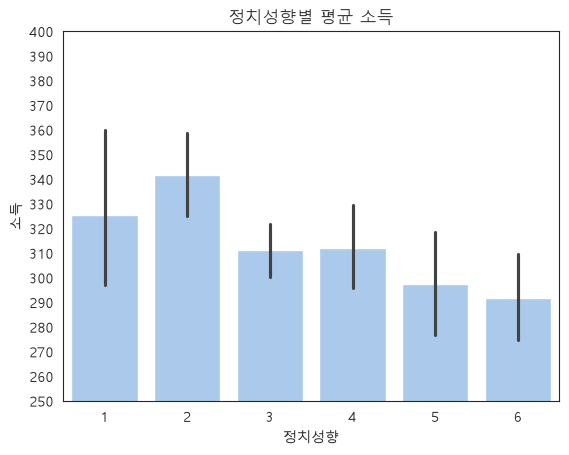

In [341]:
# nan 없애기
data['politic'] = data['politic'].dropna()

# 정수로 변환
data['politic'] = data['politic'].astype(int)

# 그래프 코드
sns.barplot(x='politic', y='income', data=data)

# y축 설정 (범위 및 눈금)
plt.ylim(250, 400)
plt.gca().yaxis.set_major_locator(MultipleLocator(10))

plt.title('정치성향별 평균 소득')
plt.xlabel('정치성향')
plt.ylabel('소득')
plt.show()

In [342]:
# 나이 컬럼을 정수형으로 변환
data = data.dropna(subset=['age'])
data['age'] = data['age'].astype(int)
data

,politic,income,birth,age
3,3,235.000000,1962.0,64
4,4,190.000000,1963.0,63
12,4,304.979532,1962.0,64
13,3,300.000000,1978.0,48
15,3,304.979532,2004.0,22
...,...,...,...,...
14543,2,304.979532,2004.0,22
14645,3,304.979532,2004.0,22
14778,3,304.979532,2002.0,24
14810,6,304.979532,2004.0,22


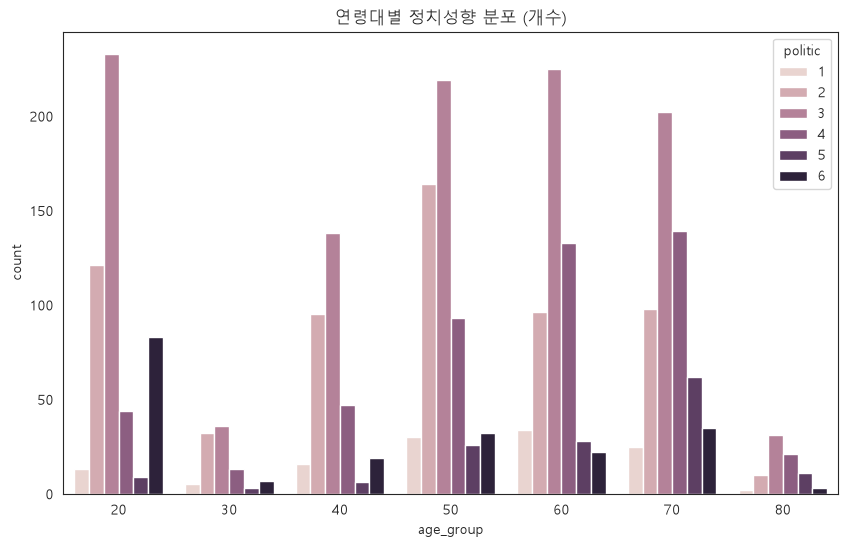

In [343]:
#연령대 그룹화 후 성향별 개수 세기
df = data.copy()
df['age_group'] = (df['age'] // 10) * 10

color_map = {1.0: 'blue', 2.0: 'red', 3.0: 'yellow'}
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', hue='politic')
plt.title('연령대별 정치성향 분포 (개수)')
plt.show()

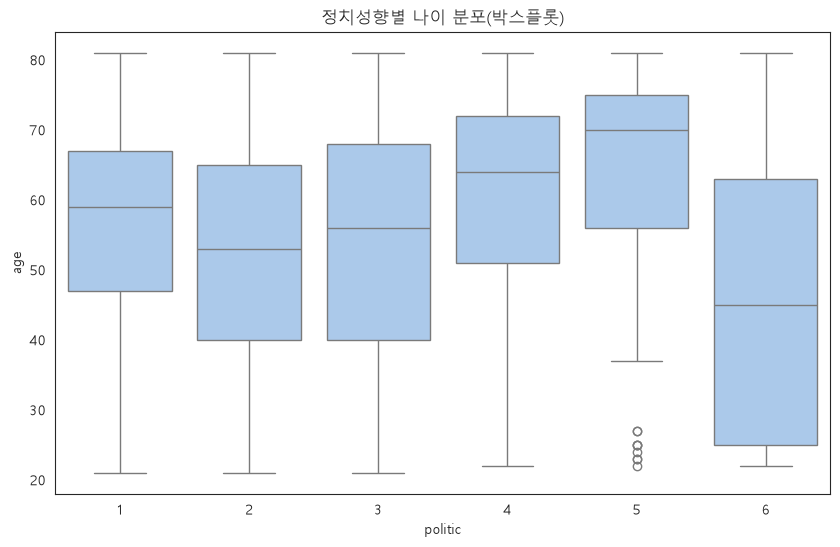

In [344]:
# 박스플롯
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='politic', y='age')
plt.title('정치성향별 나이 분포(박스플롯)')
plt.show()

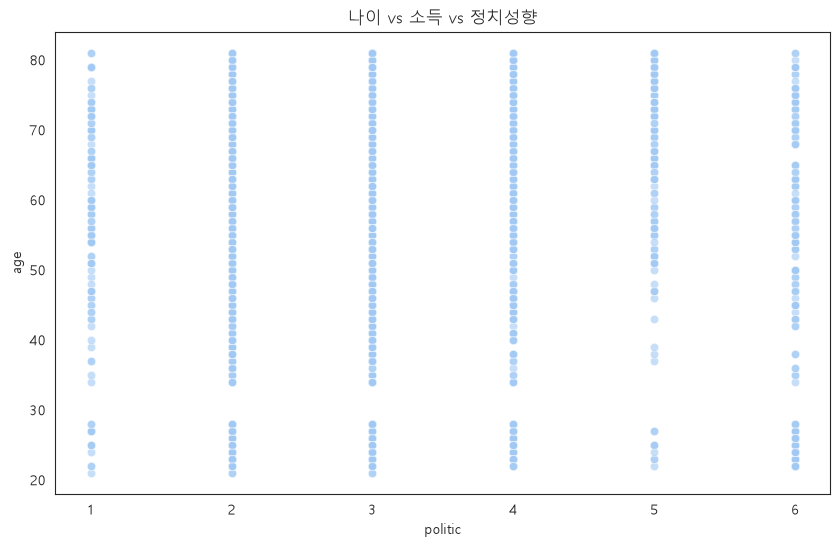

In [350]:
#나이(x), 소득(y), 정치성향
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='politic', y='age', alpha=0.6)
plt.title('나이 vs 소득 vs 정치성향')
plt.show()

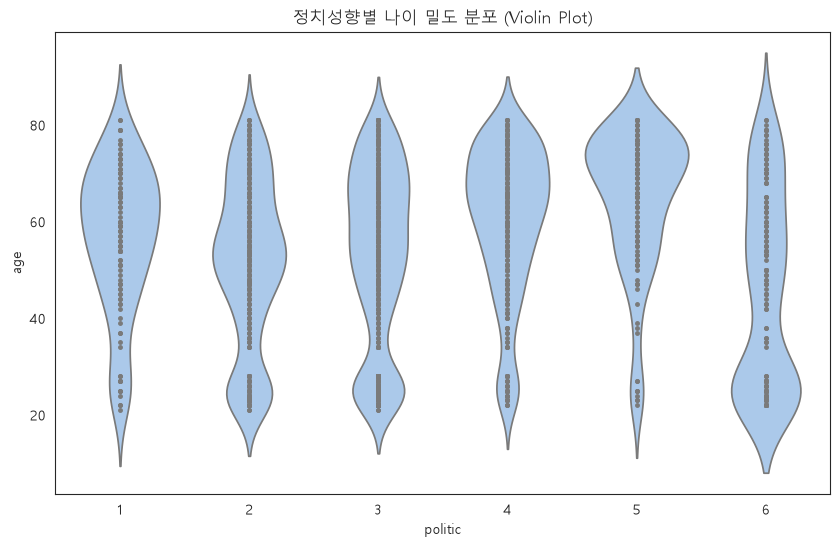

In [346]:
# 나이의 밀도를 바이올린 형태로 시각화
plt.figure(figsize=(10, 6))
sns.violinplot(data=data, x='politic', y='age', inner='points') # inner='points'로 개별점도 함께 표시
plt.title('정치성향별 나이 밀도 분포 (Violin Plot)')
plt.show()

In [347]:
# 정치성향별로 정확히 몇 명인지 숫자로 확인
print(data['politic'].value_counts())

politic
3    1084
2     616
4     490
6     201
5     145
1     125
Name: count, dtype: int64
